# 📊 Retail Sales — Exploratory Data Analysis
**Dataset:** Superstore Sales | **Parts:** 1 & 2

## 1. Setup & Data Loading

In [1]:
import sys, os
sys.path.append(os.path.join('..', 'src'))

import csv
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
# Load CSV using our custom loader
from data_loader import load_csv
rows = load_csv()
print(f'Rows loaded: {len(rows)}')

✅ Loaded 9994 rows from 'Sample - Superstore.csv'
   Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Rows loaded: 9994


## 2. Core Data Structures

In [3]:
# LIST — all orders as tuples
orders_list = [
    (row['Order ID'], row['Customer Name'], row['Product Name'],
     float(row['Sales']), float(row['Profit']))
    for row in rows
]

# DICT — unique customers
customers_dict = {}
for row in rows:
    cid = row['Customer ID']
    if cid not in customers_dict:
        customers_dict[cid] = {'name': row['Customer Name'],
                                'segment': row['Segment'],
                                'region': row['Region']}

# DICT — unique products
products_dict = {}
for row in rows:
    pid = row['Product ID']
    if pid not in products_dict:
        products_dict[pid] = {'name': row['Product Name'],
                               'category': row['Category']}

# SETS — unique values
unique_regions    = set(row['Region']   for row in rows)
unique_categories = set(row['Category'] for row in rows)

print(f'Orders (list)     : {len(orders_list)}')
print(f'Customers (dict)  : {len(customers_dict)}')
print(f'Products (dict)   : {len(products_dict)}')
print(f'Regions (set)     : {unique_regions}')
print(f'Categories (set)  : {unique_categories}')

Orders (list)     : 9994
Customers (dict)  : 793
Products (dict)   : 1862
Regions (set)     : {'Central', 'East', 'West', 'South'}
Categories (set)  : {'Furniture', 'Technology', 'Office Supplies'}


## 3. Functional Analysis

In [4]:
# Total sales
total_sales = sum(float(row['Sales']) for row in rows)
print(f'Total Sales: ${total_sales:,.2f}')

# Top 5 products
from collections import defaultdict
product_sales = defaultdict(float)
for row in rows:
    product_sales[row['Product Name']] += float(row['Sales'])
top_products = sorted(product_sales.items(), key=lambda x: x[1], reverse=True)[:5]

print('\nTop 5 Products:')
for i, (name, sales) in enumerate(top_products, 1):
    print(f'  {i}. {name[:45]:<45} ${sales:,.2f}')

# Average discount
avg_discount = sum(float(row['Discount']) for row in rows) / len(rows)
print(f'\nAverage Discount: {avg_discount*100:.2f}%')

Total Sales: $2,297,200.86

Top 5 Products:
  1. Canon imageCLASS 2200 Advanced Copier         $61,599.82
  2. Fellowes PB500 Electric Punch Plastic Comb Bi $27,453.38
  3. Cisco TelePresence System EX90 Videoconferenc $22,638.48
  4. HON 5400 Series Task Chairs for Big and Tall  $21,870.58
  5. GBC DocuBind TL300 Electric Binding System    $19,823.48

Average Discount: 15.62%


## 4. Pandas — Data Cleaning

In [5]:
df = pd.DataFrame(rows)

# Fix data types
df['Sales']      = pd.to_numeric(df['Sales'])
df['Profit']     = pd.to_numeric(df['Profit'])
df['Discount']   = pd.to_numeric(df['Discount'])
df['Quantity']   = pd.to_numeric(df['Quantity'])
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Add helper columns
df['Order Month'] = df['Order Date'].dt.to_period('M').astype(str)
df['Order Year']  = df['Order Date'].dt.year
df['Month Name']  = df['Order Date'].dt.strftime('%b')
df['Month Num']   = df['Order Date'].dt.month

print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head(3)

Shape: (9994, 25)
Missing values: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Month Name,Month Num
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2016-11,2016,Nov,11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2016-11,2016,Nov,11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,2016-06,2016,Jun,6


## 5. NumPy Statistical Analysis

In [6]:
sales    = df['Sales'].values
profit   = df['Profit'].values
quantity = df['Quantity'].values

for name, arr in [('Sales', sales), ('Profit', profit), ('Quantity', quantity)]:
    print(f'\n{name}:')
    print(f'  Mean   : {np.mean(arr):.2f}')
    print(f'  Median : {np.median(arr):.2f}')
    print(f'  Std Dev: {np.std(arr):.2f}')
    print(f'  Min    : {np.min(arr):.2f}')
    print(f'  Max    : {np.max(arr):.2f}')

# Normalization
sales_norm = (sales - np.min(sales)) / (np.max(sales) - np.min(sales))
print(f'\nNormalized sales range: {sales_norm.min():.2f} to {sales_norm.max():.2f}')


Sales:
  Mean   : 229.86
  Median : 54.49
  Std Dev: 623.21
  Min    : 0.44
  Max    : 22638.48

Profit:
  Mean   : 28.66
  Median : 8.67
  Std Dev: 234.25
  Min    : -6599.98
  Max    : 8399.98

Quantity:
  Mean   : 3.79
  Median : 3.00
  Std Dev: 2.22
  Min    : 1.00
  Max    : 14.00

Normalized sales range: 0.00 to 1.00


## 6. EDA — Sales by Region

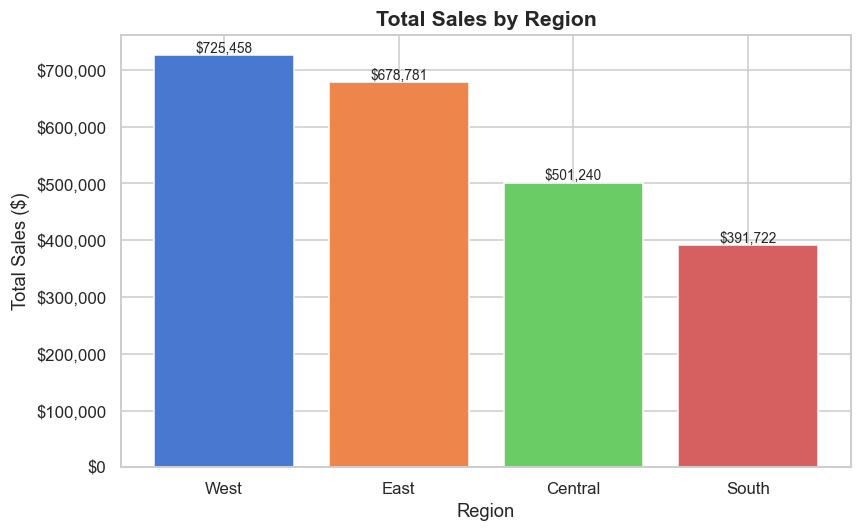

In [7]:
region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(region.index, region.values, color=sns.color_palette('muted', len(region)))
ax.set_title('Total Sales by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'${bar.get_height():,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. EDA — Monthly Sales Trend

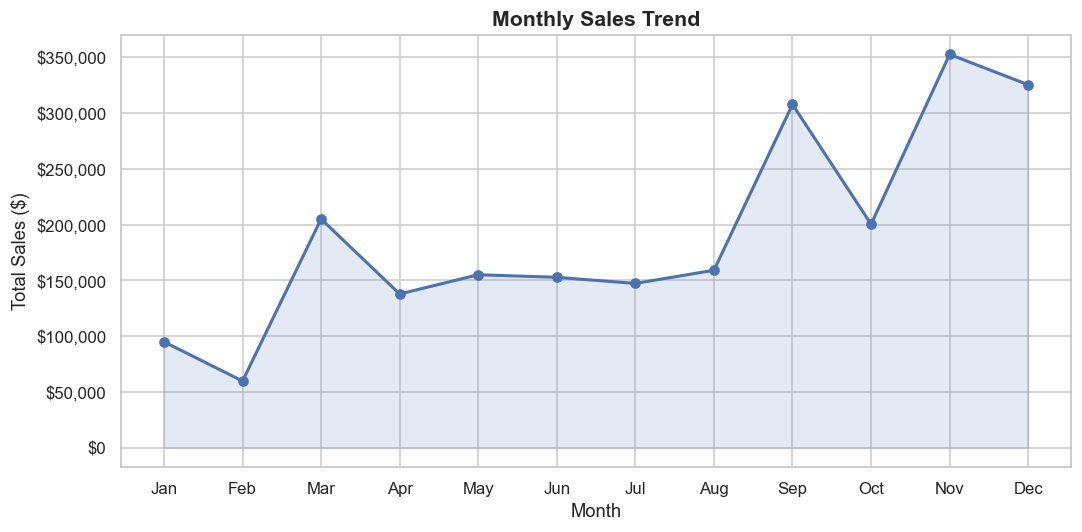

In [8]:
monthly = df.groupby(['Month Num', 'Month Name'])['Sales'].sum().reset_index().sort_values('Month Num')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly['Month Name'], monthly['Sales'], marker='o', linewidth=2, color='#4C72B0')
ax.fill_between(monthly['Month Name'], monthly['Sales'], alpha=0.15, color='#4C72B0')
ax.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 8. EDA — Top 10 Profitable Products

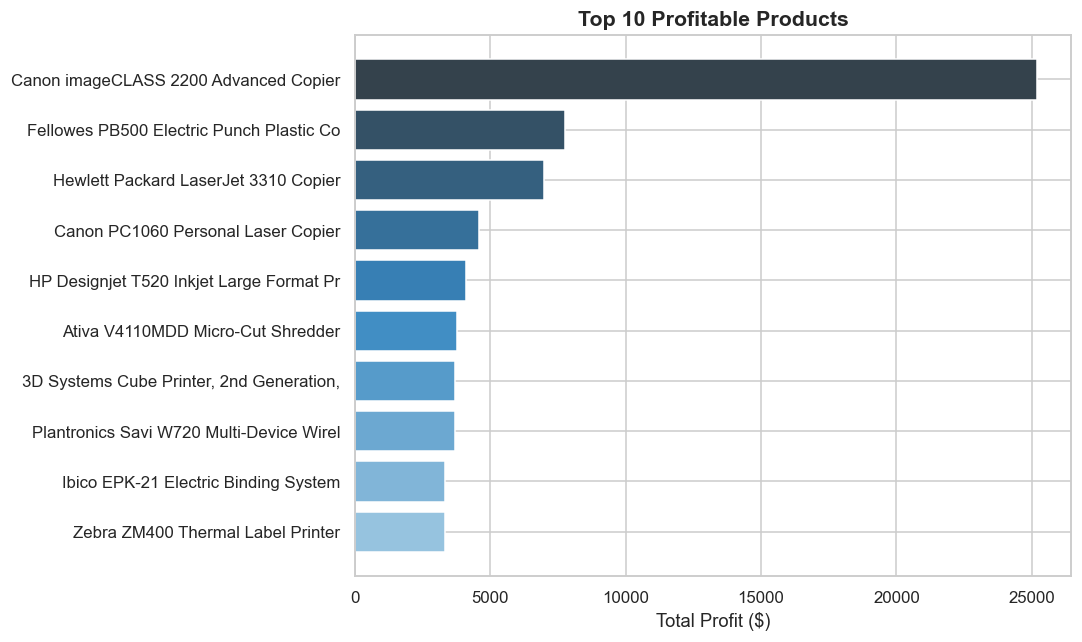

In [9]:
top = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=True).tail(10)
labels = [n[:40] for n in top.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels, top.values, color=sns.color_palette('Blues_d', len(top)))
ax.set_title('Top 10 Profitable Products', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit ($)')
plt.tight_layout()
plt.show()

## 9. EDA — Profit Heatmap by Category & Region

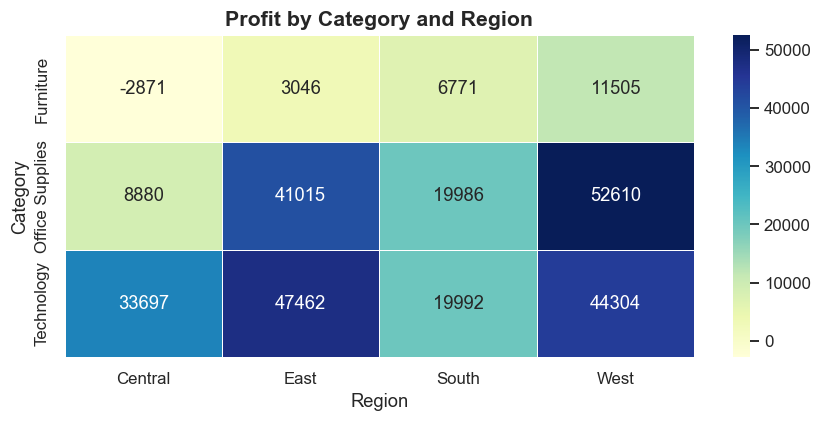

In [10]:
pivot = df.pivot_table(values='Profit', index='Category', columns='Region', aggfunc='sum').round(0)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5, ax=ax)
ax.set_title('Profit by Category and Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. EDA — Sales vs Profit Scatter

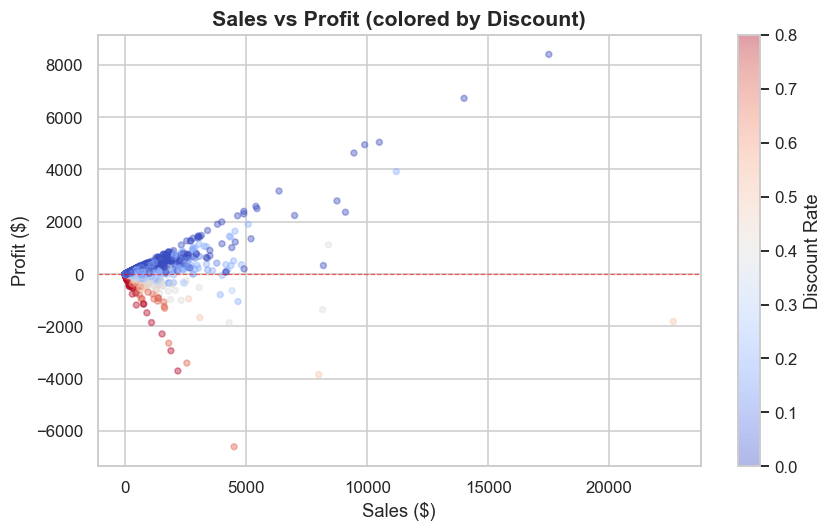


💡 Red dots = high discount orders. Notice how they cluster below the zero profit line.


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(df['Sales'], df['Profit'], c=df['Discount'],
                     cmap='coolwarm', alpha=0.4, s=15)
plt.colorbar(scatter, ax=ax, label='Discount Rate')
ax.set_title('Sales vs Profit (colored by Discount)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Profit ($)')
ax.axhline(0, color='red', linewidth=0.8, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
print('\n💡 Red dots = high discount orders. Notice how they cluster below the zero profit line.')